In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install pyxdf mne numpy matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 55.2 MB/s eta 0:00:00


Subject 1 - sekiguchi


Processing session S01...
Loading file: /content/drive/MyDrive/Tactile_neurofeedback /sub-P001 - Tactile _ses-S01_task-Default_run-001_eeg.xdf
Number of relevant markers: 20
Number of classifier results: 20
Session accuracy: 50.00%

Processing session S02...
Loading file: /content/drive/MyDrive/Tactile_neurofeedback /sub-P001 - Tactile _ses-S02_task-Default_run-001_eeg.xdf
Number of relevant markers: 20
Number of classifier results: 20
Session accuracy: 50.00%

Processing session S03...
Loading file: /content/drive/MyDrive/Tactile_neurofeedback /sub-P001 - Tactile _ses-S03_task-Default_run-001_eeg.xdf
Number of relevant markers: 20
Number of classifier results: 20
Session accuracy: 55.00%

Processing session S04...
Loading file: /content/drive/MyDrive/Tactile_neurofeedback /sub-P001 - Tactile _ses-S04_task-Default_run-001_eeg.xdf
Number of relevant markers: 18
Number of classifier results: 20
Session accuracy: 55.56%

Processing session S05...
Loading file: /content/drive/MyDrive/Tact

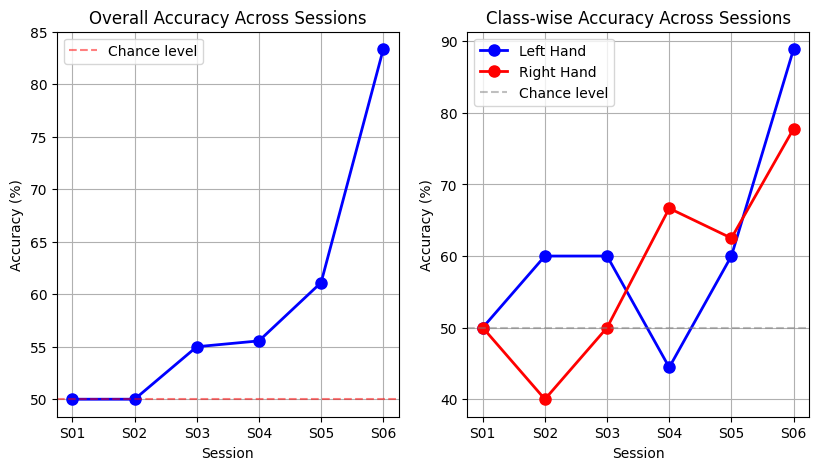

In [ ]:
import pyxdf
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

def analyze_single_session(file_path):
    try:
        # Load XDF file
        print(f"Loading file: {file_path}")
        streams, header = pyxdf.load_xdf(file_path)

        # Initialize streams
        clf_stream = None
        marker_stream = None

        # Extract relevant streams
        for stream in streams:
            if stream['info']['name'][0] == 'clfresults':
                clf_stream = stream
            elif stream['info']['name'][0] == 'si_marker':
                marker_stream = stream

        # Extract classifier results
        clf_results = clf_stream['time_series']
        clf_timestamps = clf_stream['time_stamps']

        # Extract relevant markers (8 and 16)
        markers = marker_stream['time_series']
        marker_timestamps = marker_stream['time_stamps']

        relevant_markers = []
        relevant_timestamps = []
        for marker, timestamp in zip(markers, marker_timestamps):
            if marker[0] in ['8', '16']:
                relevant_markers.append(marker[0])
                relevant_timestamps.append(timestamp)

        print(f"Number of relevant markers: {len(relevant_markers)}")
        print(f"Number of classifier results: {len(clf_results)}")

        # Convert to binary labels
        true_labels = np.array([0 if m == '16' else 1 for m in relevant_markers])
        predicted_labels = np.array([int(pred[0]) for pred in clf_results])

        # Ensure matching numbers
        min_len = min(len(true_labels), len(predicted_labels))
        true_labels = true_labels[:min_len]
        predicted_labels = predicted_labels[:min_len]

        # Calculate metrics
        accuracy = accuracy_score(true_labels, predicted_labels)
        cm = confusion_matrix(true_labels, predicted_labels)
        class_accuracy = cm.diagonal() / cm.sum(axis=1)

        print(f"Session accuracy: {accuracy*100:.2f}%")

        # Calculate trial-wise accuracy
        trial_accuracies = []
        if min_len >= 2:
            num_trials = min_len // 2
            for i in range(num_trials):
                trial_start_idx = i * 2
                trial_end_idx = (i + 1) * 2
                trial_true = true_labels[trial_start_idx:trial_end_idx]
                trial_pred = predicted_labels[trial_start_idx:trial_end_idx]
                trial_acc = accuracy_score(trial_true, trial_pred)
                trial_accuracies.append(trial_acc)

        return {
            'accuracy': accuracy,
            'class_accuracy': class_accuracy,
            'confusion_matrix': cm,
            'trial_accuracies': trial_accuracies,
            'true_labels': true_labels,
            'predicted_labels': predicted_labels
        }

    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

def analyze_all_sessions(base_path):
    # Create a list to store results from all sessions
    all_results = []
    session_numbers = range(1, 7)  # Sessions S01 to S06

    for session in session_numbers:
        # Updated file path format with new session naming (S01-S06)
        file_path = f"{base_path} /sub-P001 - Tactile _ses-S{session:02d}_task-Default_run-001_eeg.xdf"

        print(f"\nProcessing session S{session:02d}...")
        result = analyze_single_session(file_path)

        if result:
            result['session'] = f"S{session:02d}"
            all_results.append(result)

    return all_results

def plot_combined_results(all_results):
    if not all_results:
        print("No results to plot!")
        return

    # 1. Overall accuracy across sessions
    plt.figure(figsize=(15, 5))
    sessions = [r['session'] for r in all_results]
    accuracies = [r['accuracy'] * 100 for r in all_results]

    plt.subplot(131)
    plt.plot(sessions, accuracies, 'bo-', linewidth=2, markersize=8)
    plt.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='Chance level')
    plt.title('Overall Accuracy Across Sessions')
    plt.xlabel('Session')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()

    # 2. Class-wise accuracy across sessions
    plt.subplot(132)
    left_hand_acc = [r['class_accuracy'][0] * 100 for r in all_results]
    right_hand_acc = [r['class_accuracy'][1] * 100 for r in all_results]

    plt.plot(sessions, left_hand_acc, 'bo-', label='Left Hand', linewidth=2, markersize=8)
    plt.plot(sessions, right_hand_acc, 'ro-', label='Right Hand', linewidth=2, markersize=8)
    plt.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Chance level')
    plt.title('Class-wise Accuracy Across Sessions')
    plt.xlabel('Session')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)



    # Calculate and display summary statistics
    all_accuracies = np.array(accuracies)
    print("\nSummary Statistics:")
    print(f"Mean Accuracy across sessions: {np.mean(all_accuracies):.2f}% ± {np.std(all_accuracies):.2f}%")
    print("\nPer-session Accuracies:")
    for session, acc in zip(sessions, accuracies):
        print(f"{session}: {acc:.2f}%")

    # Calculate improvement
    if len(accuracies) >= 2:
        improvement = accuracies[-1] - accuracies[0]
        print(f"\nOverall Improvement (S06 vs S01): {improvement:.2f}%")

    # Additional statistics
    print("\nClass-wise Performance:")
    print("Left Hand (mean ± std):", f"{np.mean(left_hand_acc):.2f}% ± {np.std(left_hand_acc):.2f}%")
    print("Right Hand (mean ± std):", f"{np.mean(right_hand_acc):.2f}% ± {np.std(right_hand_acc):.2f}%")

    plt.show()

# Run the analysis with the exact base path
base_path = '/content/drive/MyDrive/Tactile_neurofeedback'
results = analyze_all_sessions(base_path)
plot_combined_results(results)

subject 2 - naomichi